# Quantum Intrusion Detection System (QIDS) - Data Preprocessing
---
#### Εισαγωγή & Φόρτωση Δεδομένων

Αυτό το notebook αποτελεί το κύριο περιβάλλον προετοιμασίας του συνόλου δεδομένων NSL-KDD, το οποίο θα χρησιμοποιηθεί στα πλαίσια της πτυχιακής εργασίας για την εκπαίδευση κβαντικών αλγορίθμων.

Αρχικά, φορτώνουμε τα ακατέργαστα δεδομένα (.txt) και ορίζουμε τα ονόματα των στηλών. Στη συνέχεια, για λόγους ευκολίας και μελλοντικής ταχύτητας, αποθηκεύουμε ένα αντίγραφο σε μορφή .csv. Αν και η ανάλυσή μας θα βασιστεί απευθείας στα DataFrames (εσωτερική μνήμη), το αρχείο αυτό θα διευκολύνει την οπτική επισκόπηση των δεδομένων.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import os
from sklearn.preprocessing import TargetEncoder
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


# Αν ο τρέχων φάκελος είναι ο 'notebooks', πήγαινε έναν φάκελο πίσω (στο root)
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

print(f"Τρέχων φάκελος εργασίας: {os.getcwd()}")


Τρέχων φάκελος εργασίας: /mnt/Main/src/ship/Quantum-IDS-NSLKDD


__Ορισμός των ονομάτων στηλών, καθώς το αρχικό dataset δεν περιέχει headers__

In [3]:
col_names = [
'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins',
'logged_in', 'num_compromised', 'root_shell', 'su_attempted',
'num_root', 'num_file_creations', 'num_shells', 'num_access_files',
'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count',
'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate',
'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate',
'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate',
'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
'dst_host_srv_rerror_rate', 'label', 'difficulty_level'
]

__Φόρτωση του dataset__

In [4]:
df = pd.read_csv('data/KDDTrain+_20Percent.txt', sep=',', names=col_names)
print(f"Διαστάσεις αρχικού dataset: {df.shape}")
display(df.head()) 

Διαστάσεις αρχικού dataset: (25192, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


__DataVisualation__

Running t-SNE dimensionality reduction... This might take a minute.


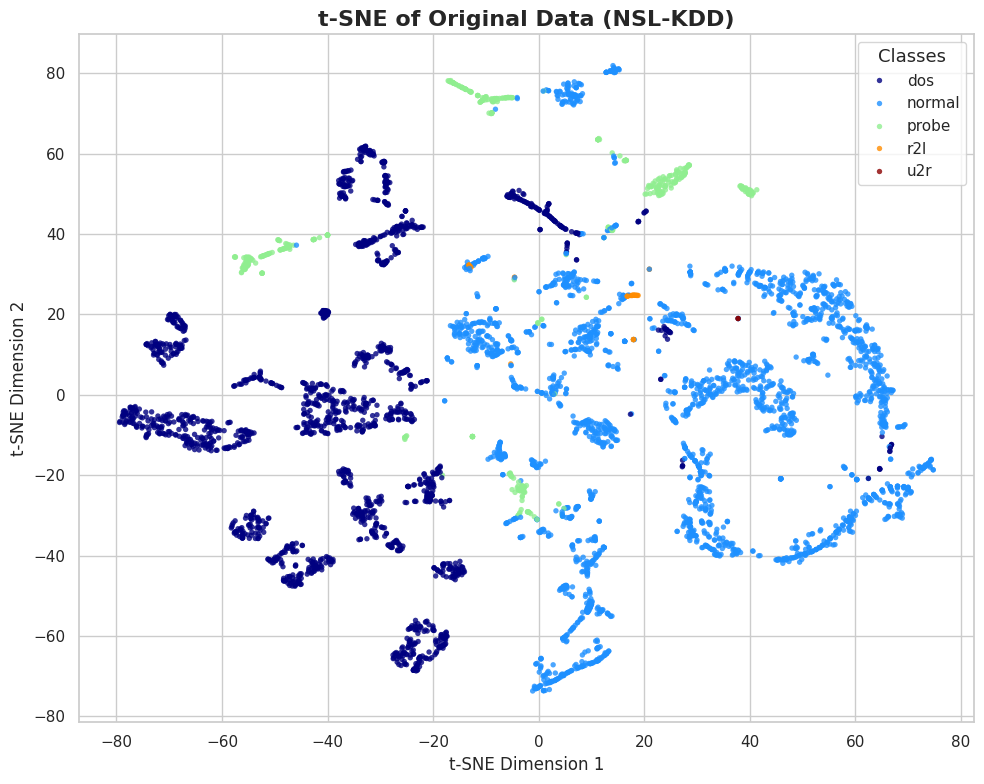

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. Map the specific attacks to the 5 main KDD classes
attack_mapping = {
    'normal': 'normal',
    
    # DoS
    'neptune': 'dos', 'smurf': 'dos', 'pod': 'dos', 'teardrop': 'dos', 
    'land': 'dos', 'back': 'dos', 'apache2': 'dos', 'udpstorm': 'dos', 
    'processtable': 'dos', 'mailbomb': 'dos',
    
    # Probe
    'portsweep': 'probe', 'ipsweep': 'probe', 'satan': 'probe', 
    'nmap': 'probe', 'mscan': 'probe', 'saint': 'probe',
    
    # R2L
    'guess_passwd': 'r2l', 'ftp_write': 'r2l', 'imap': 'r2l', 'phf': 'r2l', 
    'multihop': 'r2l', 'warezmaster': 'r2l', 'warezclient': 'r2l', 'spy': 'r2l', 
    'xlock': 'r2l', 'xsnoop': 'r2l', 'snmpguess': 'r2l', 'snmpgetattack': 'r2l', 
    'httptunnel': 'r2l', 'sendmail': 'r2l', 'named': 'r2l',
    
    # U2R
    'buffer_overflow': 'u2r', 'loadmodule': 'u2r', 'rootkit': 'u2r', 
    'perl': 'u2r', 'sqlattack': 'u2r', 'xterm': 'u2r', 'ps': 'u2r'
}

# Apply the mapping to a new column
df['attack_class'] = df['label'].map(attack_mapping)

df_sampled = df.sample(n=5000, random_state=42).copy()

X_viz = df_sampled.drop(columns=['label', 'difficulty_level', 'attack_class'])
y_viz = df_sampled['attack_class']

categorical_cols = ['protocol_type', 'service', 'flag']
le = LabelEncoder()
for col in categorical_cols:
    X_viz[col] = le.fit_transform(X_viz[col])

# Scale the features (Crucial for t-SNE)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_viz)

# 4. Apply t-SNE
print("Running t-SNE dimensionality reduction... This might take a minute.")
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

# Create a DataFrame for plotting
tsne_df = pd.DataFrame(data=X_tsne, columns=['TSNE_1', 'TSNE_2'])
tsne_df['Class'] = y_viz.values

custom_palette = {
    'dos': '#000080',      # Navy Blue
    'normal': '#1E90FF',   # Dodger Blue
    'probe': '#90EE90',    # Light Green
    'r2l': '#FF8C00',      # Dark Orange
    'u2r': '#8B0000'       # Dark Red
}

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='TSNE_1', y='TSNE_2', 
    hue='Class', 
    palette=custom_palette, 
    data=tsne_df, 
    s=15,          # Dot size
    alpha=0.8,     # Transparency
    linewidth=0    # Remove borders around dots
)

plt.title('t-SNE of Original Data (NSL-KDD)', fontsize=16, fontweight='bold')
plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)
plt.legend(title='Classes', title_fontsize='13', fontsize='11', loc='best')
plt.tight_layout()
plt.show()

__Αποθήκευση σε μορφή CSV για ευκολότερη μελλοντική πρόσβαση__

In [4]:
file_path = 'data/KDDTrain+_20Percent.csv'

if not os.path.exists(file_path):
    df.to_csv(file_path, index=False)
    print(f"Το dataset αποθηκεύτηκε επιτυχώς στο: {file_path}")
else:

    print(f"Το αρχείο {file_path} υπάρχει ήδη. Παράλειψη αποθήκευσης.")

Το αρχείο data/KDDTrain+_20Percent.csv υπάρχει ήδη. Παράλειψη αποθήκευσης.


## 1. Διαχωρισμός και Κανονικοποίηση Δεδομένων (Data Splitting & Normalization)
---
__Στρατηγικός Διαχωρισμός (Stratified Split)__ :
    Για την αξιολόγηση του μοντέλου, είναι απαραίτητος ο διαχωρισμός του dataset σε σύνολα εκπαίδευσης (Train set) και δοκιμής (Test set). Προκειμένου ο διαχωρισμός να είναι "δίκαιος" και αντιπροσωπευτικός, θα εφαρμόσουμε τεχνικές διαστρωμάτωσης (stratification). Αυτό διασφαλίζει ότι κρίσιμα χαρακτηριστικά διατηρούν την ίδια κατανομή και στα δύο υποσύνολα, αποτρέποντας το μοντέλο από το να αγνοήσει σπάνιες επιθέσεις.

__Κανονικοποίηση (Normalization)__ :
    Τα χαρακτηριστικά του δικτύου έχουν τελείως διαφορετικές κλίμακες μέτρησης (π.χ. bytes έναντι ποσοστιαίων ρυθμών). Είναι κρίσιμο να κανονικοποιήσουμε αυτές τις πληροφορίες σε μια κοινή κλίμακα, ώστε να είναι συγκρίσιμες και να μπορούν να τροφοδοτηθούν αποδοτικά στα κβαντικά κυκλώματα (Qubits).

#### Εξαγωγή Χαρακτηριστικών: Κατηγοριοποίηση του Μεγέθους Πακέτου (src_bytes_cat)

Για έναν ορθό διαστρωματωμένο διαχωρισμό, επιλέγουμε δύο βασικούς άξονες:
1. __Ετικέτα Κίνησης (Label)__ : Η βασικότερη μετρική, καθώς καθορίζει τη φύση της κίνησης (κανονική ή επίθεση).
2. __Μέγεθος Πακέτου (Source Bytes)__: Αν και σπάνια χρησιμοποιείται ως κύριο κριτήριο διαχωρισμού, παρέχει ζωτική πληροφορία για τη φυσική υπόσταση του πακέτου. Επειδή το μέγεθος των πακέτων παρουσιάζει τεράστια διασπορά, θα το κατηγοριοποιήσουμε σε ομάδες (bins).

Με αυτόν τον τρόπο, ετικετοποιούμε τα πακέτα ως low, medium, ή high ανάλογα με τον όγκο δεδομένων τους. Αυτό εξασφαλίζει ότι το μοντέλο μας θα εκπαιδευτεί και θα δοκιμαστεί σε πανομοιότυπες συνθήκες δικτυακής κίνησης.

Βήματα που ακολουθούν:
- Δημιουργία της νέας κατηγορικής μεταβλητής μεγέθους.
- Εφαρμογή του διαχωρισμού (Train/Test) διατηρώντας την κατανομή.

#### Χωρισμός του src_bytes σε 3 ισοπληθή διαστήματα (quantiles)

In [5]:
df['src_bytes_cat'] = pd.qcut(df['src_bytes'], q=4, duplicates='drop', labels=['low', 'medium', 'high'])

print("Ποσοστιαία κατανομή κατηγοριών μεγέθους πακέτου:")
print(df['src_bytes_cat'].value_counts(normalize=True).apply(lambda x: f"{x:.2%}"))

Ποσοστιαία κατανομή κατηγοριών μεγέθους πακέτου:
src_bytes_cat
low       50.94%
high      24.96%
medium    24.09%
Name: proportion, dtype: str


#### Έλεγχος των ορίων κάθε κατηγορίας

In [6]:
check_bins = df.groupby('src_bytes_cat', observed=True)['src_bytes'].agg(['min', 'max', 'count'])
print("\nΌρια κατηγοριών (min, max bytes) και πλήθος εγγραφών:")
display(check_bins)


Όρια κατηγοριών (min, max bytes) και πλήθος εγγραφών:


,min,max,count
src_bytes_cat,,,
low,0,44,12834
medium,45,279,6069
high,280,381709090,6289


#### Δημιουργία σύνθετης βοηθητικής στήλης για τον διαστρωματωμένο διαχωρισμό (Label + Size Category)

In [7]:
df['strat_col'] = df['label'].astype(str) + "_" + df['src_bytes_cat'].astype(str)

#### Εντοπισμός συνδυασμών που εμφανίζονται λιγότερο από 2 φορές (αδύνατο να χωριστούν σε train/test)

In [8]:
counts = df['strat_col'].value_counts()
problematic_combinations = counts[counts < 2].index

print(f"Αρχικό πλήθος προβληματικών (σπάνιων) συνδυασμών: {len(problematic_combinations)}")

Αρχικό πλήθος προβληματικών (σπάνιων) συνδυασμών: 12


#### Αντιμετώπιση: Για τους σπάνιους συνδυασμούς, κρατάμε μόνο το βασικό Label παραλείποντας το μέγεθος

In [9]:
mask = df['strat_col'].isin(problematic_combinations)
df.loc[mask, 'strat_col'] = df.loc[mask, 'label']

#### Τελικός Έλεγχος μετά τη διόρθωση

In [10]:
final_counts = df['strat_col'].value_counts()
remaining_singles = final_counts[final_counts < 2]

print(f"Εναπομείνασες μοναδικές εγγραφές (που υπάρχουν μόνο μία φορά στο dataset): {len(remaining_singles)}")

if len(remaining_singles) > 0:
    print("\nΠΡΟΣΟΧΗ: Οι παρακάτω επιθέσεις είναι απολύτως μοναδικές στο dataset:")
print(remaining_singles)

Εναπομείνασες μοναδικές εγγραφές (που υπάρχουν μόνο μία φορά στο dataset): 8

ΠΡΟΣΟΧΗ: Οι παρακάτω επιθέσεις είναι απολύτως μοναδικές στο dataset:
strat_col
portsweep      1
ftp_write      1
warezmaster    1
land           1
loadmodule     1
satan          1
spy            1
ipsweep        1
Name: count, dtype: int64


#### Διαχείριση Μοναδικών Εγγραφών (Outlier Handling)

Οι σπάνιες επιθέσεις που εντοπίστηκαν παραπάνω (και εμφανίζονται μόνο μία φορά σε ολόκληρο το dataset), αποτελούν ειδική περίπτωση.

Για να διασφαλίσουμε ότι το μοντέλο μας θα έρθει σε επαφή μαζί τους κατά τη διάρκεια της εκπαίδευσης, θα απομονωθούν και θα εισαχθούν αποκλειστικά στο Training Set. Ο υπόλοιπος, "κανονικός" όγκος δεδομένων θα χωριστεί κανονικά με τη μέθοδο 80-20.

#### Διαχωρισμός των μοναδικών εγγραφών από τον κορμό του dataset

In [11]:
single_mask = df['strat_col'].isin(remaining_singles.index)
df_singles = df[single_mask]     # Σπάνιες εγγραφές (Μόνο για Train)
df_majority = df[~single_mask]   # Κύριος όγκος δεδομένων (Προς διαχωρισμό)

#### Στρατηγικός διαχωρισμός 80-20 στον κύριο όγκο

In [12]:
train_majority, test_set = train_test_split(
df_majority,
test_size=0.2,
random_state=42,
stratify=df_majority['strat_col']
)

#### Επανασύνδεση των σπάνιων εγγραφών στο Training Set

In [13]:
train_set = pd.concat([train_majority, df_singles])

#### Αφαίρεση της βοηθητικής στήλης 'strat_col' καθώς επιτέλεσε τον σκοπό της

In [14]:
test_set = test_set.drop(columns=['strat_col'])
train_set = train_set.drop(columns=['strat_col'])
df = df.drop(columns=['strat_col'], errors='ignore')

print(f"Διαστάσεις τελικού Training Set: {train_set.shape}")
print(f"Διαστάσεις τελικού Test Set: {test_set.shape}")

Διαστάσεις τελικού Training Set: (20155, 44)
Διαστάσεις τελικού Test Set: (5037, 44)


#### Διαχωρισμός χαρακτηριστικών (Features) και στόχων (Labels)
Αφαιρούμε και τη στήλη 'difficulty_level' καθώς δεν αφορά την δημιουργία του μοντέλου

In [15]:
xTrain = train_set.drop(columns=['label', 'difficulty_level'])
yTrain = train_set['label']

xTest = test_set.drop(columns=['label', 'difficulty_level'])
yTest = test_set['label']

## 2. Κωδικοποίηση Κατηγορικών Μεταβλητών (Feature Encoding)
---
__Επιλογή__: Target Encoding
Σε αντίθεση με κλασικές τεχνικές όπως το One-Hot Encoding που προκαλούν τεράστια αύξηση των διαστάσεων (dimensionality explosion), εδώ επιλέγεται το Target Encoding με γνώμονα την Κβαντική Οικονομία.

Με αυτή την τεχνική, κάθε κατηγορική τιμή αντικαθίσταται από τη στατιστική πιθανότητα εμφάνισης επίθεσης, όπως υπολογίστηκε στο σύνολο εκπαίδευσης.
- Παράδειγμα: Αν το TCP λάβει την τιμή 0.7, σημαίνει ότι το 70% των TCP συνδέσεων στο Train set ήταν κακόβουλες επιθέσεις. Αντίστοιχα, αν το UDP λάβει 0.2, σημαίνει 20%.
- Σημασιολογική Αξία: Η σύγκριση 0.7 > 0.2 δίνει στο μοντέλο την άμεση πληροφορία ότι το TCP είναι στατιστικά πιο "επικίνδυνο", επιτρέποντάς μας να συμπυκνώσουμε την πληροφορία του δικτύου μειώνοντας δραστικά τον απαιτούμενο αριθμό Qubits.

__Επιλογή των στηλών που απαιτούν κωδικοποίηση__

In [16]:
categorical_cols = ['protocol_type', 'service', 'flag', 'src_bytes_cat']

__Δημιουργία δυαδικού στόχου (0 για φυσιολογική κίνηση, 1 για επιθέσεις)__
<sub>Σημείωση: Στο NSL-KDD η κλάση αναφοράς τερματίζει σε τελεία ('normal.')</sub>

In [17]:
yTrainBinary = np.where(yTrain == 'normal.', 0, 1)

__Αρχικοποίηση Target Encoder, αυτόματη εξομάλυνση (smoothing) για αποφυγή υπερεκπαίδευσης (overfitting) σε σπάνιες κλάσεις__

In [18]:
encoder = TargetEncoder(target_type='binary', smooth="auto")

__Εκπαίδευση στο Train και "τυφλός" μετασχηματισμός στο Test για αποφυγή Data Leakage__

In [19]:
xTrain_encoded = encoder.fit_transform(xTrain[categorical_cols], yTrainBinary)
xTest_encoded = encoder.transform(xTest[categorical_cols])

__Επαναφορά των κωδικοποιημένων πινάκων σε DataFrames__

In [20]:
df_encoded_train = pd.DataFrame(xTrain_encoded, columns=categorical_cols, index=xTrain.index)
df_encoded_test = pd.DataFrame(xTest_encoded, columns=categorical_cols, index=xTest.index)

__Αντικατάσταση των παλιών κατηγορικών στηλών με τις νέες κωδικοποιημένες__

In [21]:
xTrain_final = pd.concat([xTrain.drop(columns=categorical_cols), df_encoded_train], axis=1)
xTest_final = pd.concat([xTest.drop(columns=categorical_cols), df_encoded_test], axis=1)

print(f"Τελικές διαστάσεις Training Set: {xTrain_final.shape}")
print(f"Τελικές διαστάσεις Test Set: {xTest_final.shape}")

Τελικές διαστάσεις Training Set: (20155, 42)
Τελικές διαστάσεις Test Set: (5037, 42)


## 3. Κανονικοποίηση Κλίμακας (Feature Scaling)
---
Πριν την εφαρμογή μεθόδων μείωσης διαστάσεων (PCA) και της εισόδου στα κβαντικά κυκλώματα, είναι απαραίτητο να κανονικοποιήσουμε τα δεδομένα. Εφαρμόζουμε StandardScaler, ο οποίος κεντράρει τα δεδομένα γύρω από το μηδέν (mean = 0) με τυπική απόκλιση 1 (variance = 1), δίνοντάς μας αριθμητικές αξίες ιδανικές για PCA.

In [22]:
scaler = StandardScaler()

__Υπολογισμός των παραμέτρων στο Train και εφαρμογή__

In [23]:
xTrain_scaled = scaler.fit_transform(xTrain_final)

__Εφαρμογή των ίδιων παραμέτρων στο Test__

In [24]:
xTest_scaled = scaler.transform(xTest_final)

## 4. Μείωση Διαστάσεων (Principal Component Analysis - PCA)
---
Για να λειτουργήσει αποδοτικά το Quantum Machine Learning (QML) στα σημερινά NISQ συστήματα, πρέπει να βελτιστοποιήσουμε τον διαθέσιμο κβαντικό χώρο.

Στοχεύουμε στη συμπίεση της πληροφορίας σε ακριβώς 16 κύριες συνιστώσες (components).
Αυτός ο αριθμός αποτελεί τον "χρυσό κανόνα" της αρχιτεκτονικής μας, καθώς:
- Επιτρέπει την πλήρη αξιοποίηση των 24 καταστάσεων Hilbert σε μόλις 4 Qubits (για __Amplitude Encoding__).
- Παρέχει ένα ρηχό και διαχειρίσιμο κύκλωμα 16 Qubits (για __Angle Encoding__) για ταχύτατες προσομοιώσεις με χαμηλό θόρυβο.

__Ορισμός PCA με στόχο τις 16 συνιστώσες__

In [25]:
pca = PCA(n_components=16)

xTrain_pca = pca.fit_transform(xTrain_scaled)
xTest_pca = pca.transform(xTest_scaled)

__Αξιολόγηση της πληροφορίας που διασώθηκε__

In [26]:
explained_variance = pca.explained_variance_ratio_.sum()

print(f"Ποσοστό πληροφορίας που διατηρήθηκε (Explained Variance): {explained_variance:.2%}")
print("Στόχος επετεύχθη: Διαμόρφωση 16 στηλών, έτοιμες για κβαντική ενσωμάτωση (Amplitude: 4 Qubits | Angle: 16 Qubits).")

Ποσοστό πληροφορίας που διατηρήθηκε (Explained Variance): 86.78%
Στόχος επετεύχθη: Διαμόρφωση 16 στηλών, έτοιμες για κβαντική ενσωμάτωση (Amplitude: 4 Qubits | Angle: 16 Qubits).


In [30]:
import numpy as np
import os

# ΑΦΑΙΡΕΘΗΚΕ Η ΤΕΛΕΙΑ ΑΠΟ ΤΟ 'normal'
yTrain_bin = np.where(yTrain == 'normal', 0, 1) 
yTest_bin = np.where(yTest == 'normal', 0, 1)

# Επαναπροσδιορισμός των features (υποθέτοντας ότι έχεις κάνει το PCA)
xTrain_norm = xTrain_pca
xTest_norm = xTest_pca

# Αποθήκευση με τα ΔΙΟΡΘΩΜΕΝΑ labels
save_dir = os.path.expanduser('~/Documents/projects/Quantum-IDS-NSLKDD/npz/')
file_path = os.path.join(save_dir, 'nslkdd_pca_ready.npz')
os.makedirs(save_dir, exist_ok=True)

np.savez(file_path, 
         xTrain_norm=xTrain_norm,
         xTest_norm=xTest_norm, 
         yTrain_bin=yTrain_bin,
         yTest_bin=yTest_bin)

print("Τα διορθωμένα δεδομένα αποθηκεύτηκαν!")

Τα διορθωμένα δεδομένα αποθηκεύτηκαν!
